<a href="https://colab.research.google.com/github/cgm2179/Branch_2_Diffusion_Transformer_efficiency_for_small_model/blob/main/Section%207%20-%20Cameron's%20Version/regime%201%20-%20Autoencoder/07_backprop_100M.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 7 — CNN Autoencoder · Backprop **100M** (ceiling reference)
A ~100M ConvAE trained by Adam+BCE, recreating binarized MNIST (plain reconstruction).

## Step 0 — Setup

In [12]:
import os, time, math, json
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('torch', torch.__version__, '| device:', device)
if device == 'cpu':
    print('WARNING: no GPU. Built for an A100 Colab runtime; set SMOKE=True to sanity-check on CPU.')

torch 2.11.0+cu128 | device: cuda


## Config (100M, backprop)

In [13]:
METHOD = 'backprop_100M'
LR_BP = 1e-3
METHOD_CFG = dict(LR_BP=LR_BP)
CORRUPT_SIGMA = 0.0
CONV_C, LATENT = 512, 896   # ~99M
BATCH = 64
EVAL_N, EVAL_BATCH = 4096, 512
DRIVE_SUBDIR = 'Section7_r1_autoencoder'

TIME_BUDGET_HOURS = 1.5
SEED = 0
LOG_EVERY_SEC, CKPT_EVERY_SEC, PLOT_EVERY_SEC, HEARTBEAT_EVERY_SEC = 30, 120, 1800, 60
USE_DRIVE = True
SMOKE = False
if SMOKE:
    CONV_C, LATENT = 8, 16
    TIME_BUDGET_HOURS = 30/3600
    LOG_EVERY_SEC,CKPT_EVERY_SEC,PLOT_EVERY_SEC,HEARTBEAT_EVERY_SEC=1,2,999,1
    EVAL_N,EVAL_BATCH,USE_DRIVE=512,512,False

## Step 1 — Storage (Drive) + paths

In [14]:
if USE_DRIVE:
    try:
        from google.colab import drive; drive.mount('/content/drive')
        STORE = os.path.join('/content/drive/MyDrive', DRIVE_SUBDIR)
    except Exception as e:
        print('Drive mount failed -> local /content (will NOT survive disconnect):', e)
        STORE = os.path.join('/content', DRIVE_SUBDIR)
else:
    STORE = os.path.join('.', DRIVE_SUBDIR)
RESULTS_DIR = os.path.join(STORE, 'results')
CKPT_DIR    = os.path.join(STORE, 'checkpoints')
FIG_DIR     = os.path.join(STORE, 'figures')
for d in (RESULTS_DIR, CKPT_DIR, FIG_DIR): os.makedirs(d, exist_ok=True)
RESULTS_PATH = os.path.join(RESULTS_DIR, f'{METHOD}.json')
CKPT_PATH    = os.path.join(CKPT_DIR,    f'{METHOD}.pt')
print('storing under:', STORE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
storing under: /content/drive/MyDrive/Section7_r1_autoencoder


## Step 2 — Model

In [15]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvAE(nn.Module):
    """Conv encoder -> dense latent bottleneck -> Upsample+Conv decoder -> 28x28 logits.
    No BatchNorm (vmap-clean); Upsample+Conv instead of ConvTranspose (vmap-safe)."""
    def __init__(self, conv_c=48, latent=98):
        super().__init__()
        c2 = 2 * conv_c
        self.enc = nn.Sequential(
            nn.Conv2d(1, conv_c, 3, stride=2, padding=1), nn.ReLU(),   # 28 -> 14
            nn.Conv2d(conv_c, c2, 3, stride=2, padding=1), nn.ReLU(),  # 14 -> 7
        )
        self._c2 = c2
        self.fc1 = nn.Linear(c2 * 7 * 7, latent)
        self.fc2 = nn.Linear(latent, c2 * 7 * 7)
        self.dec = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),               # 7 -> 14
            nn.Conv2d(c2, conv_c, 3, padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),               # 14 -> 28
            nn.Conv2d(conv_c, 1, 3, padding=1),
        )
    def forward(self, x):
        h = self.enc(x)
        b = h.shape[0]
        z = self.fc1(h.reshape(b, -1))
        h2 = self.fc2(z).reshape(b, self._c2, 7, 7)
        return self.dec(h2)                                            # (B,1,28,28) logits

## Step 3 — Data

In [16]:
import torchvision
_tr = torchvision.datasets.MNIST('./data', train=True,  download=True)
_te = torchvision.datasets.MNIST('./data', train=False, download=True)
Xtr = (_tr.data.float()/255.0 > 0.5).float().unsqueeze(1).to(device)   # (60000,1,28,28) in {0,1}
Xte_all = (_te.data.float()/255.0 > 0.5).float().unsqueeze(1).to(device)
if SMOKE:
    Xtr, Xte_all = Xtr[:2000], Xte_all[:512]

def _corrupt(x):
    return x + CORRUPT_SIGMA * torch.randn_like(x) if CORRUPT_SIGMA > 0 else x

torch.manual_seed(SEED)                                                # reproducible eval corruption
Xte_tgt = Xte_all[:EVAL_N]
Xte_in  = _corrupt(Xte_tgt)
_bg = 1.0 - Xte_tgt.mean().item()                                      # all-background pixel-accuracy baseline

def fresh_batch(n):
    idx = torch.randint(0, Xtr.shape[0], (n,), device=device)
    xb = Xtr[idx]
    return _corrupt(xb), xb                                            # (input, clean target)
print(f'binarized MNIST | train {tuple(Xtr.shape)} | corrupt sigma={CORRUPT_SIGMA} | all-background pixel-acc baseline={_bg:.3f}')

binarized MNIST | train (60000, 1, 28, 28) | corrupt sigma=0.0 | all-background pixel-acc baseline=0.876


## Step 4 — Build (100M) + provenance

In [17]:
torch.manual_seed(SEED)
model = ConvAE(CONV_C, LATENT).to(device)
P = sum(p.numel() for p in model.parameters())
print(f'METHOD={METHOD} | ConvAE P = {P:,} (target ~100M) | conv_c={CONV_C} latent={LATENT} corrupt={CORRUPT_SIGMA}')
CFG = dict(METHOD=METHOD, SEED=SEED, CONV_C=CONV_C, LATENT=LATENT, BATCH=BATCH, CORRUPT_SIGMA=CORRUPT_SIGMA, TIME_BUDGET_HOURS=TIME_BUDGET_HOURS)
CFG.update(METHOD_CFG)

METHOD=backprop_100M | ConvAE P = 99,414,913 (target ~100M) | conv_c=512 latent=896 corrupt=0.0


## Step 5 — Trainer (Adam backprop)

In [18]:
torch.manual_seed(SEED)
net = ConvAE(CONV_C, LATENT).to(device)
opt = torch.optim.Adam(net.parameters(), lr=LR_BP)
def forward_fn(x): return net(x)
def train_step():
    xb, yb = fresh_batch(BATCH)
    opt.zero_grad(); loss = F.binary_cross_entropy_with_logits(net(xb), yb); loss.backward(); opt.step()
    return loss.item()
def ckpt_state():      return {'net': net.state_dict(), 'opt': opt.state_dict()}
def load_ckpt_state(d): net.load_state_dict(d['net']); opt.load_state_dict(d['opt'])

## Step 6 — Eval / checkpoint / live-plot

In [19]:
@torch.no_grad()
def eval_metrics():
    bce_sum = 0.0; correct = 0; ne = 0
    for i in range(0, Xte_tgt.shape[0], EVAL_BATCH):
        logits = forward_fn(Xte_in[i:i+EVAL_BATCH]); tgt = Xte_tgt[i:i+EVAL_BATCH]
        bce_sum += F.binary_cross_entropy_with_logits(logits, tgt, reduction='sum').item()
        correct += ((logits > 0) == (tgt > 0.5)).sum().item()          # sigmoid(logit)>0.5 <=> logit>0
        ne += tgt.numel()
    return bce_sum/ne, correct/ne                                       # (mean BCE/pixel, pixel-accuracy)

In [20]:
def _atomic_save(obj, path):
    tmp = path + '.tmp'; torch.save(obj, tmp); os.replace(tmp, path)

def save_checkpoint(step, elapsed, logs):
    _atomic_save({'loop': {'step': step, 'elapsed_sec': elapsed, 'logs': logs},
                  'method': ckpt_state(), 'config': CFG}, CKPT_PATH)

def maybe_resume():
    if os.path.exists(CKPT_PATH):
        d = torch.load(CKPT_PATH, map_location=device)
        load_ckpt_state(d['method']); L = d['loop']
        print(f'[resume] {METHOD}: step {L["step"]:,}, elapsed {L["elapsed_sec"]/3600:.2f}h -> continuing.')
        return L['step'], L['elapsed_sec'], L['logs']
    return 0, 0.0, []

In [21]:
def live_plot(logs, final=False):
    if not logs: return
    hrs = [l[0]/3600 for l in logs]; tr=[l[3] for l in logs]; te=[l[4] for l in logs]; acc=[l[5] for l in logs]
    if not final: clear_output(wait=True)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(hrs, tr, '-', color='#999', label='train BCE'); ax[0].plot(hrs, te, 'o-', color='#C62828', label='test BCE')
    ax[0].set_xlabel('elapsed hours'); ax[0].set_ylabel('BCE / pixel'); ax[0].set_title(f'{METHOD}: BCE vs time'); ax[0].legend()
    ax[1].plot(hrs, acc, 'o-', color='#1F3864')
    if '_bg' in dir(): ax[1].axhline(_bg, color='gray', ls='--', lw=1, label=f'all-bg {_bg:.2f}'); ax[1].legend()
    ax[1].set_xlabel('elapsed hours'); ax[1].set_ylabel('pixel accuracy'); ax[1].set_title('pixel-acc vs time')
    plt.tight_layout()
    try: fig.savefig(os.path.join(FIG_DIR, f'{METHOD}_progress.png'), dpi=90)
    except Exception as e: print('savefig failed:', e)
    plt.show()
    last = logs[-1]; print(f'[h={last[0]/3600:.2f}] step={last[1]:,} test_bce={last[4]:.4f} pixel_acc={last[5]:.4f}')

## Step 7 — Train (equal wall-clock, heartbeat) + save results

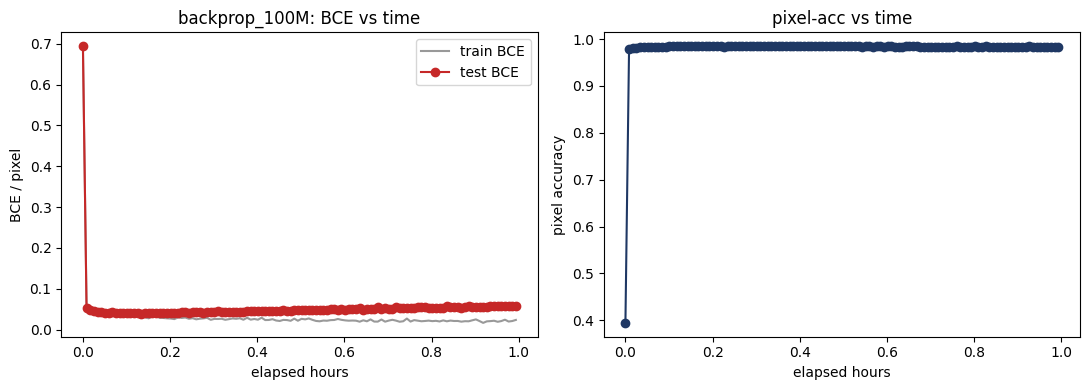

[h=0.99] step=228,884 test_bce=0.0572 pixel_acc=0.9838
[backprop_100M] h=1.00 step=230,629 train=0.0236 test_bce=0.0572 pixel_acc=0.9838
[backprop_100M] h=1.02 step=234,566 train=0.0178 test_bce=0.0568 pixel_acc=0.9838
[backprop_100M] h=1.04 step=238,125 train=0.0217 test_bce=0.0587 pixel_acc=0.9838
[backprop_100M] h=1.05 step=242,058 train=0.0188 test_bce=0.0611 pixel_acc=0.9834
[backprop_100M] h=1.07 step=245,811 train=0.0190 test_bce=0.0587 pixel_acc=0.9839
[backprop_100M] h=1.09 step=249,748 train=0.0179 test_bce=0.0592 pixel_acc=0.9839
[backprop_100M] h=1.10 step=253,502 train=0.0214 test_bce=0.0611 pixel_acc=0.9835
[backprop_100M] h=1.12 step=257,438 train=0.0226 test_bce=0.0590 pixel_acc=0.9839
[backprop_100M] h=1.14 step=261,195 train=0.0186 test_bce=0.0602 pixel_acc=0.9836
[backprop_100M] h=1.15 step=265,133 train=0.0226 test_bce=0.0579 pixel_acc=0.9838
[backprop_100M] h=1.17 step=268,890 train=0.0189 test_bce=0.0588 pixel_acc=0.9839
[backprop_100M] h=1.19 step=272,830 train=0

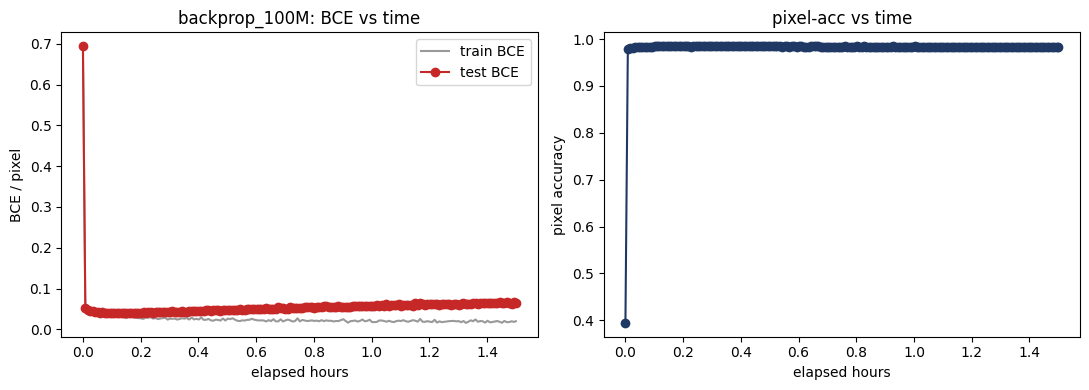

[h=1.50] step=345,572 test_bce=0.0646 pixel_acc=0.9836
wrote /content/drive/MyDrive/Section7_r1_autoencoder/results/backprop_100M.json
DONE backprop_100M: 345,572 steps, 1.50h, pixel-acc 0.9836 (bg 0.876), best BCE 0.0391


In [22]:
def write_results(step, elapsed, logs):
    te = [l[4] for l in logs]; acc = [l[5] for l in logs]
    summary = dict(initial_bce=logs[0][4], final_bce=logs[-1][4], best_bce=min(te),
                   final_acc=logs[-1][5], best_acc=max(acc), bg_baseline=_bg)
    peak = torch.cuda.max_memory_allocated()/1e6 if device == 'cuda' else float('nan')
    out = dict(meta=dict(method=METHOD, device=device, seed=SEED, P=P, config=CFG, note='all MEASURED-here',
                         wall_clock_sec=elapsed, total_steps=step, samples=step*BATCH, peak_mem_mb=peak),
               curve=dict(t_sec=[l[0] for l in logs], step=[l[1] for l in logs], samples=[l[2] for l in logs],
                          train_bce=[l[3] for l in logs], test_bce=te, test_acc=acc),
               summary=summary)
    with open(RESULTS_PATH, 'w') as f: json.dump(out, f, indent=2)
    print('wrote', RESULTS_PATH)

def run():
    step, elapsed0, logs = maybe_resume()
    t0 = time.time(); budget = TIME_BUDGET_HOURS*3600
    last_ckpt = last_plot = last_log = last_beat = elapsed0
    if not logs:
        b0, a0 = eval_metrics(); logs.append((elapsed0, step, 0, b0, b0, a0))
    tl = logs[-1][3]; printed = False
    while True:
        elapsed = elapsed0 + (time.time() - t0)
        if elapsed >= budget: break
        tl = train_step(); step += 1
        if not printed:
            dt = time.time() - t0
            print(f'[{METHOD}] step 1 = {dt:.2f}s -> ~{int(budget/max(dt,1e-9)):,} steps fit the budget.', flush=True); printed = True
        if elapsed - last_log >= LOG_EVERY_SEC:
            bce, acc = eval_metrics(); logs.append((elapsed, step, step*BATCH, tl, bce, acc)); last_log = elapsed
        if elapsed - last_beat >= HEARTBEAT_EVERY_SEC:
            L = logs[-1]
            print(f'[{METHOD}] h={elapsed/3600:.2f} step={step:,} train={L[3]:.4f} test_bce={L[4]:.4f} pixel_acc={L[5]:.4f}', flush=True)
            last_beat = elapsed
        if elapsed - last_ckpt >= CKPT_EVERY_SEC:
            save_checkpoint(step, elapsed, logs); last_ckpt = elapsed
        if elapsed - last_plot >= PLOT_EVERY_SEC:
            live_plot(logs); last_plot = elapsed
    elapsed = elapsed0 + (time.time() - t0)
    bce, acc = eval_metrics(); logs.append((elapsed, step, step*BATCH, tl, bce, acc))
    save_checkpoint(step, elapsed, logs); live_plot(logs, final=True); write_results(step, elapsed, logs)
    print(f'DONE {METHOD}: {step:,} steps, {elapsed/3600:.2f}h, pixel-acc {acc:.4f} (bg {_bg:.3f}), best BCE {min(l[4] for l in logs):.4f}')

run()

## How to run
- `SMOKE=True` first (~30 s tiny model), then `False` → Runtime → Run all on an A100.
- Backprop can train 100M fine (the probe rule can't — cost ~P²), so this is the **ceiling** reference. Same equal-wall-clock harness: heartbeat, Drive checkpoint/auto-resume, live plot, `results/backprop_100M.json`.
- Reduce `BATCH` if you hit CUDA OOM.